# Data processing and analysis

Processing private_second from /Users/avshah/P_llm_auctions/llm-auction/experiment_logs/V10/private_second_price


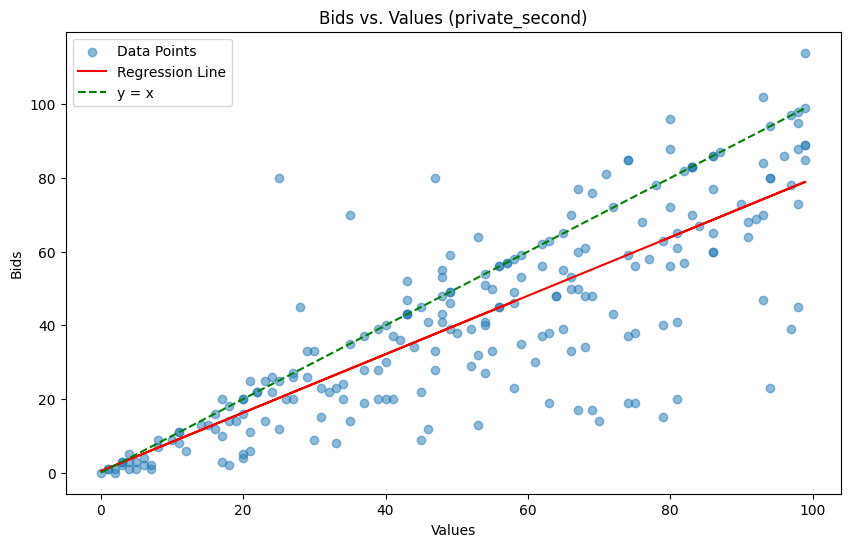

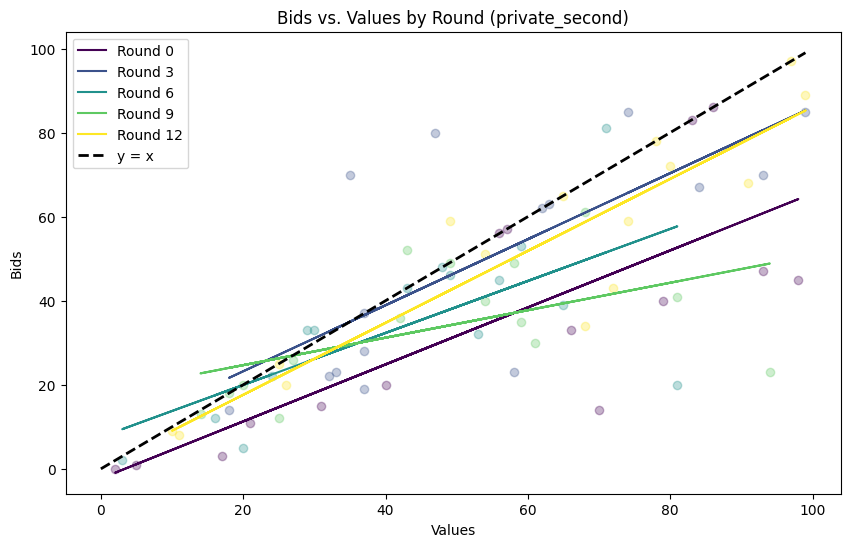

Processing menu_intervention from /Users/avshah/P_llm_auctions/llm-auction/experiment_logs/V10/intervention_menu


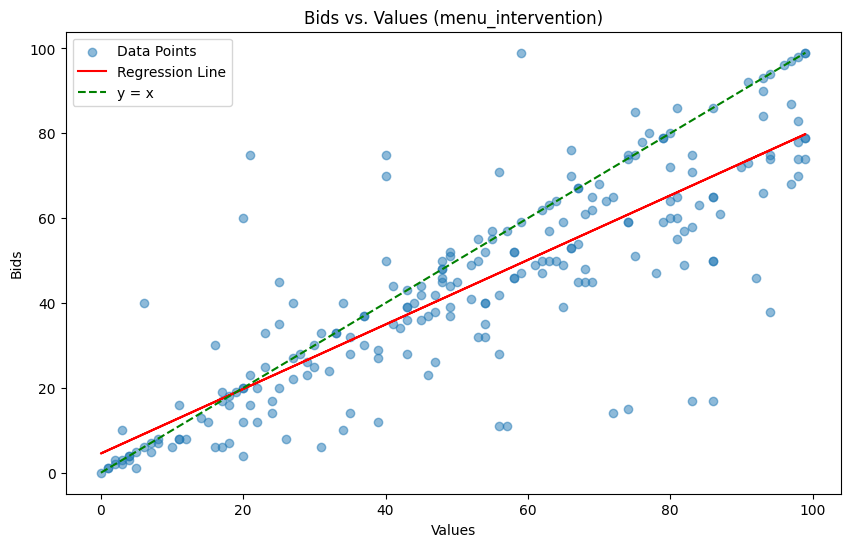

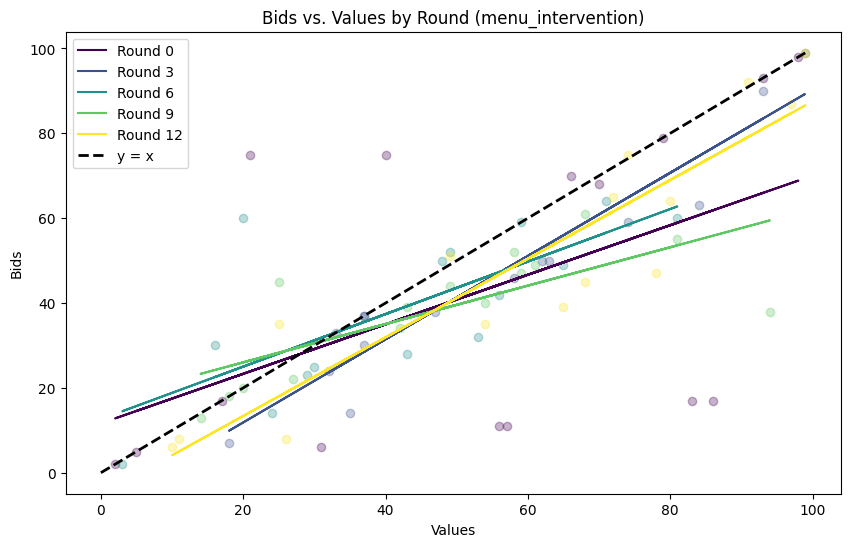

Processing proxy_intervention from /Users/avshah/P_llm_auctions/llm-auction/experiment_logs/V10/intervention_proxy_breitmoser


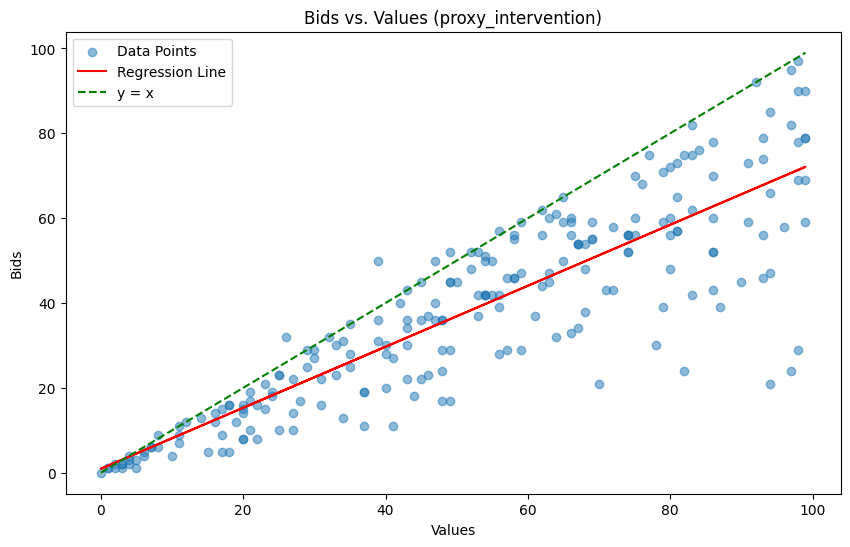

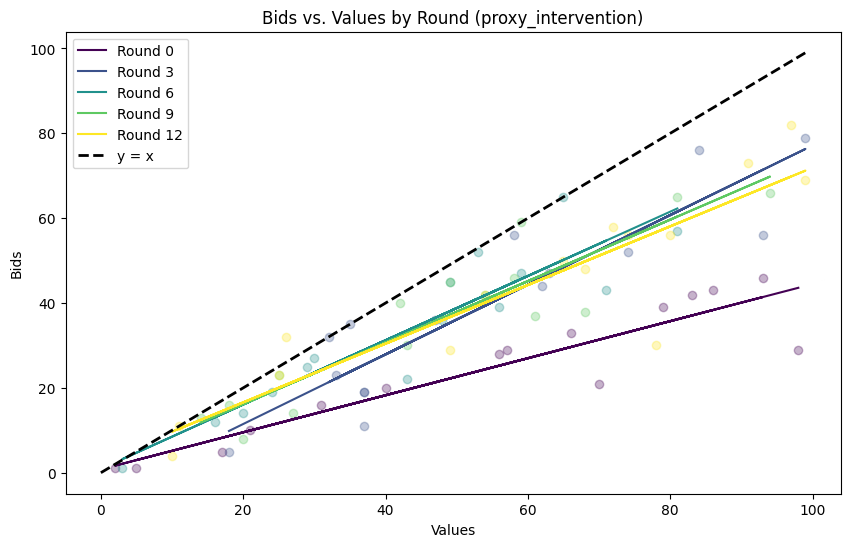

Processing nash_intervention from /Users/avshah/P_llm_auctions/llm-auction/experiment_logs/V10/intervention_nash_deviation


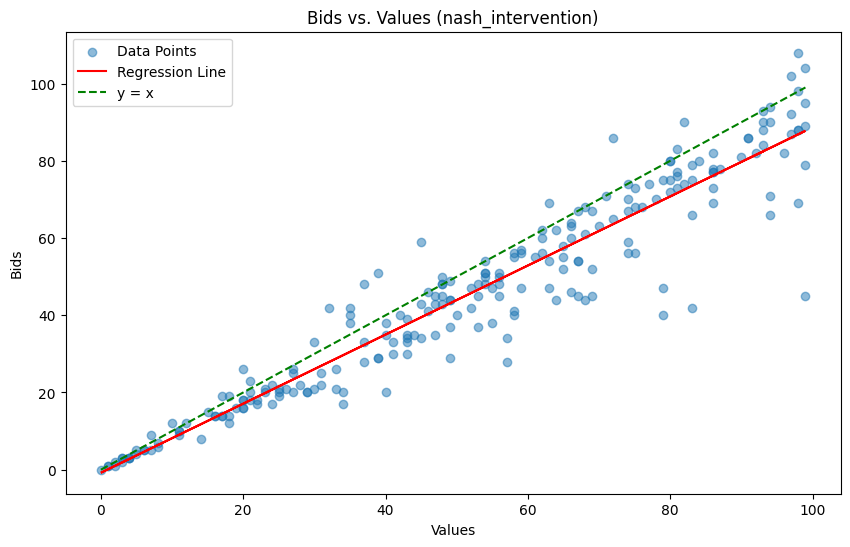

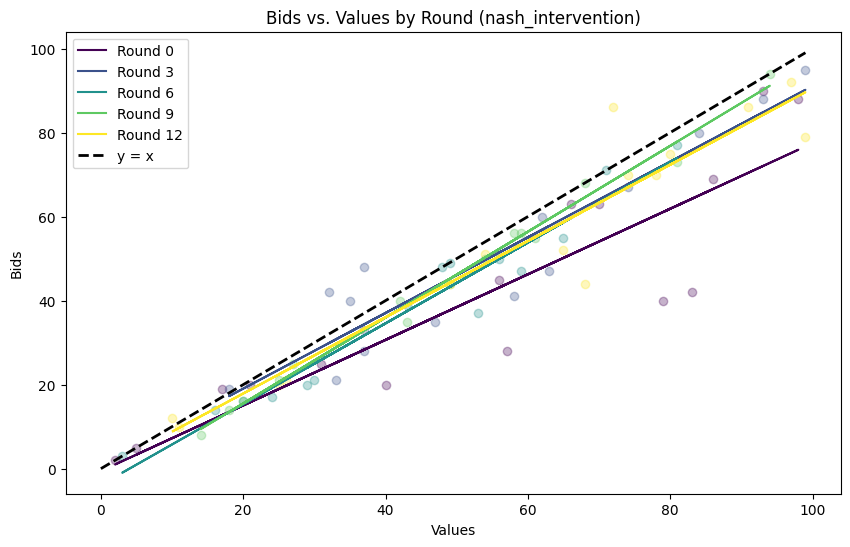

Processing dominant_strat_intervention from /Users/avshah/P_llm_auctions/llm-auction/experiment_logs/V10/intervention_NE_strat_reveal


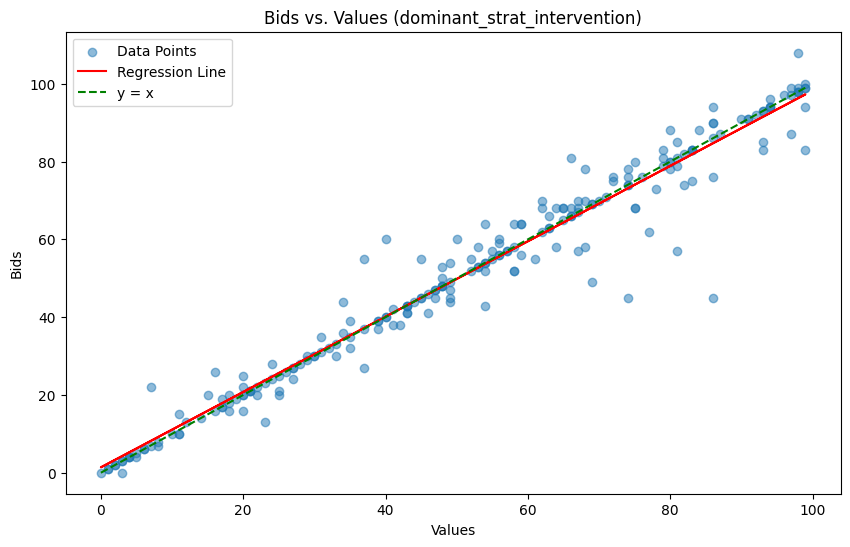

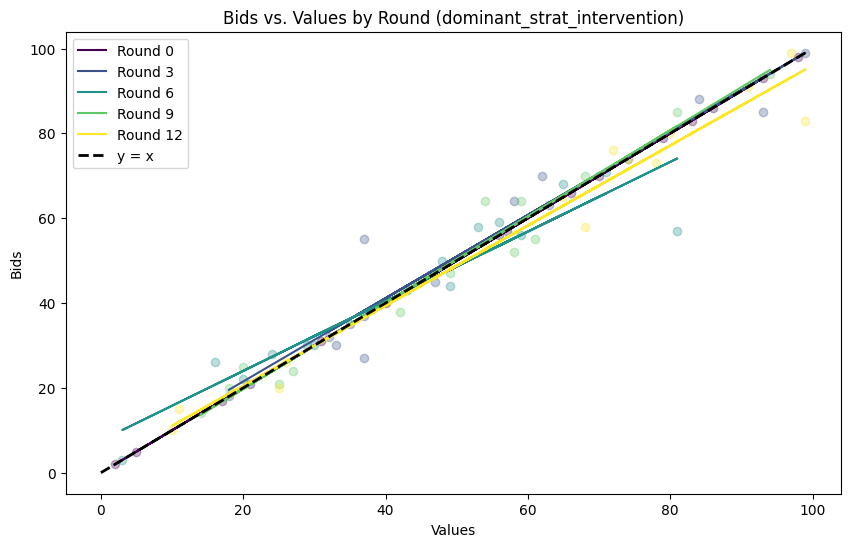

Processing wrong_strat_intervention from /Users/avshah/P_llm_auctions/llm-auction/experiment_logs/V10/intervention_wrong_strat_reveal


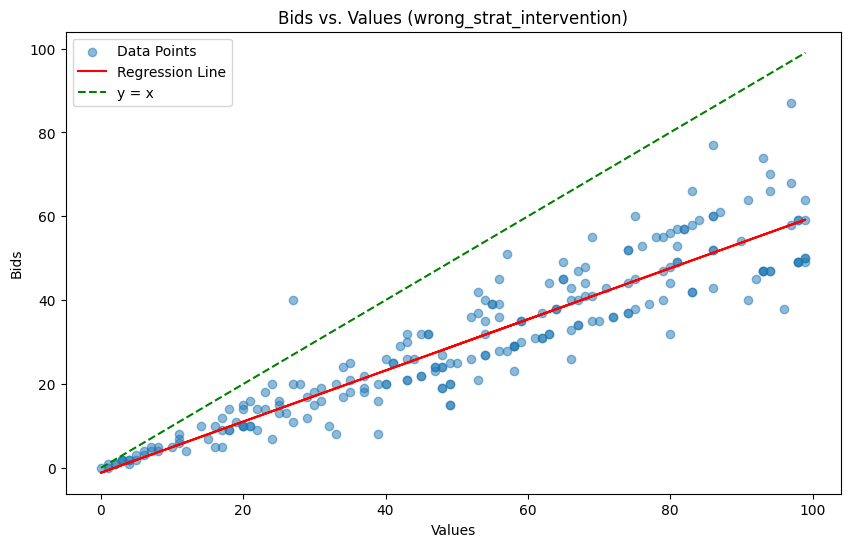

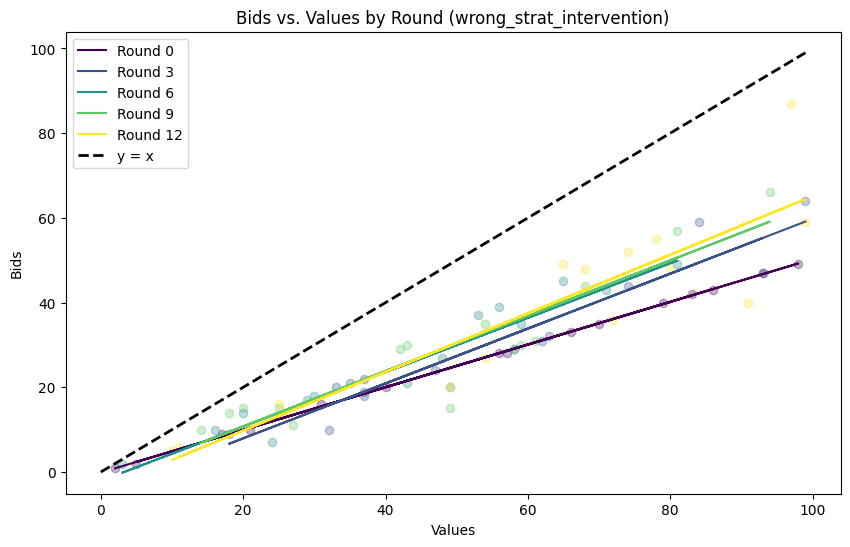

Processing risk_intervention from /Users/avshah/P_llm_auctions/llm-auction/experiment_logs/V10/intervention_risk_neutrality


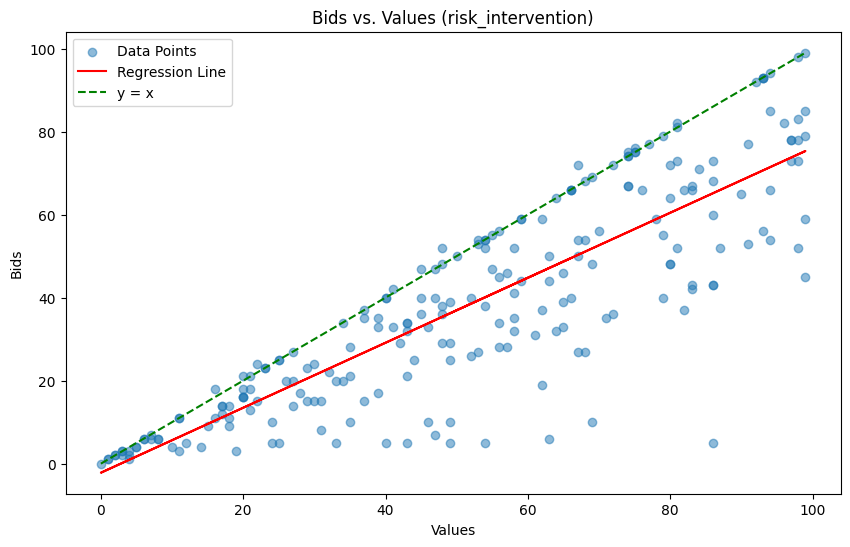

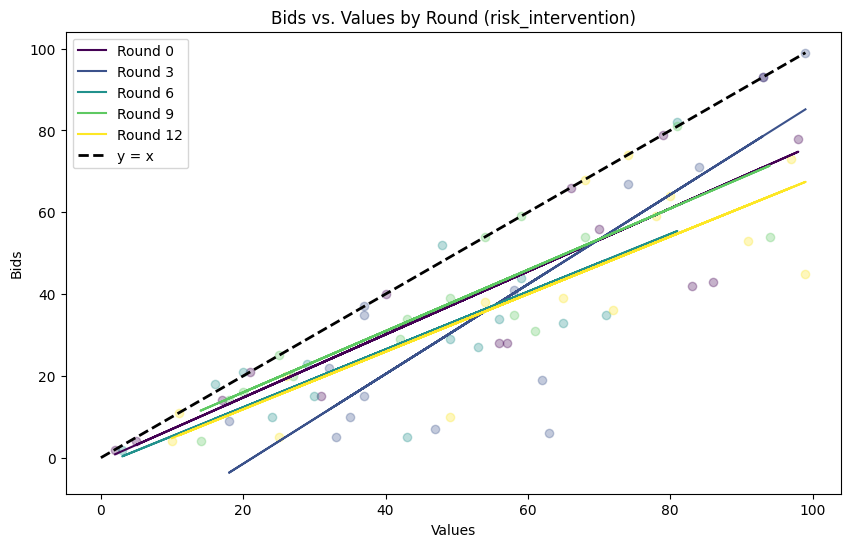

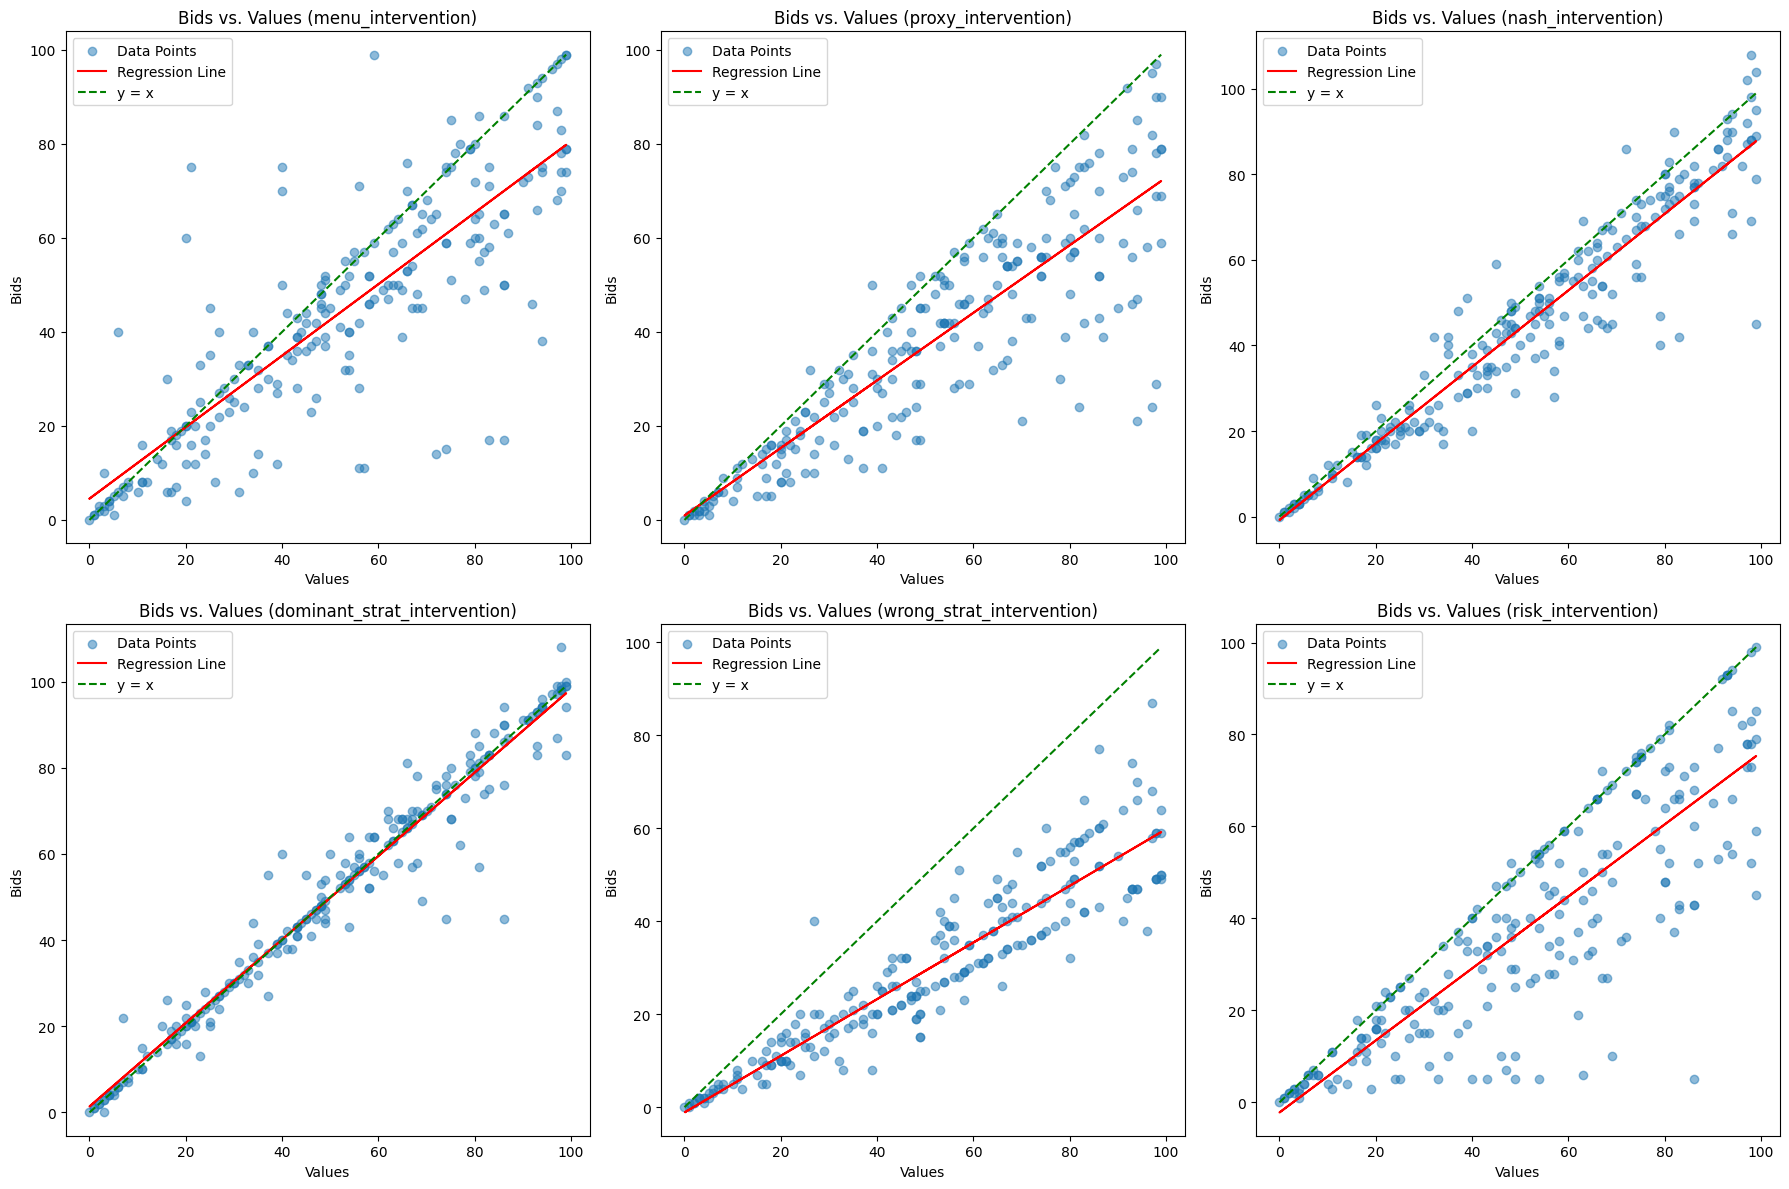

Regression and Skewness Test Results:
                 Experiment  Observations  Proportional Bias (α) Proportional Bias p-value  Noise (σ)  Intercept Intercept p-value  Slope Slope p-value  R-squared  Residual Skew  Skew Test Statistic Skew Test p-value
             private_second           225                 -0.200                  6.7e-115     15.562      0.435             0.842  0.793       5.0e-56      0.673         -0.349               -2.148             0.032
          menu_intervention           225                 -0.172                  7.3e-126     14.201      4.535             0.023  0.760       6.8e-60      0.698         -0.159               -0.998             0.318
         proxy_intervention           225                 -0.267                  4.3e-134     11.503      0.933             0.564  0.719       3.3e-70      0.756         -0.985               -5.320           1.0e-07
          nash_intervention           225                 -0.117                  2.0e-183    

In [25]:
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import skew, skewtest
import warnings

warnings.filterwarnings('ignore', message='use_inf_as_na option is deprecated')

# --- Helper Functions for Data Aggregation ---

def extract_bid_value_pairs(row):
    """Extract bid and value lists from a row."""
    values = row.get("Values", [])
    bids = row.get("Bids", [])
    return values, bids

def aggregate_bid_value_pairs(df):
    """
    Aggregates bid and value pairs across all rows.
    
    Returns:
        X: numpy array of values.
        y: numpy array of bids.
    """
    bid_values = []
    bids = []
    for _, row in df.iterrows():
        values, bid_list = extract_bid_value_pairs(row)
        for value, bid in zip(values, bid_list):
            bid_values.append(value)
            bids.append(bid)
    return np.array(bid_values), np.array(bids)

# --- Original Plotting Functions ---

def plot_bid_value(df, label=""):
    """
    Plots bid vs. value along with a regression line and the y = x reference line.
    """
    X, y = aggregate_bid_value_pairs(df)
    if len(X) == 0:
        print(f"No bid-value data for {label}.")
        return
    X_with_const = sm.add_constant(X)
    model = sm.OLS(y, X_with_const).fit()
    regression_line = model.predict(X_with_const)
    
    x_range = np.linspace(X.min(), X.max(), 100)
    y_line = x_range
    
    plt.figure(figsize=(10,6))
    plt.scatter(X, y, alpha=0.5, label="Data Points")
    plt.plot(X, regression_line, color='red', label="Regression Line")
    plt.plot(x_range, y_line, color='green', linestyle='dashed', label="y = x")
    plt.xlabel("Values")
    plt.ylabel("Bids")
    plt.title(f"Bids vs. Values ({label})")
    plt.legend()
    plt.show()

def plot_by_round(df, step=5, label=""):
    """
    Plots bid-value pairs and regression lines for selected rounds.
    """
    rounds_sorted = sorted(df["Round"].dropna().unique())
    if not rounds_sorted:
        print(f"No rounds found for {label}.")
        return
    selected_rounds = rounds_sorted[::step]
    plt.figure(figsize=(10,6))
    colors = plt.cm.viridis(np.linspace(0, 1, len(selected_rounds)))
    for round_num, color in zip(selected_rounds, colors):
        group = df[df["Round"] == round_num]
        bid_values = []
        bids = []
        for _, row in group.iterrows():
            values, bid_list = extract_bid_value_pairs(row)
            for value, bid in zip(values, bid_list):
                bid_values.append(value)
                bids.append(bid)
        if len(bid_values) == 0:
            continue
        X = np.array(bid_values)
        y_vals = np.array(bids)
        X_with_const = sm.add_constant(X)
        model = sm.OLS(y_vals, X_with_const).fit()
        regression_line = model.predict(X_with_const)
        plt.scatter(X, y_vals, color=color, alpha=0.3)
        plt.plot(X, regression_line, color=color, label=f"Round {round_num}")
    overall_X, _ = aggregate_bid_value_pairs(df)
    if len(overall_X) > 0:
        x_range_all = np.linspace(overall_X.min(), overall_X.max(), 100)
        plt.plot(x_range_all, x_range_all, color='black', linestyle='dashed', linewidth=2, label="y = x")
    plt.xlabel("Values")
    plt.ylabel("Bids")
    plt.title(f"Bids vs. Values by Round ({label})")
    plt.legend()
    plt.show()

def plot_percent_error(df, label=""):
    """
    Computes and plots the average percent error (bid - value relative to value) by round.
    """
    def calculate_percent_error(row):
        errors = []
        values = row.get("Values", [])
        bids = row.get("Bids", [])
        for value, bid in zip(values, bids):
            if value != 0:
                errors.append((bid - value) / value)
            else:
                errors.append(np.nan)
        return errors
    
    df = df.copy()
    df["Percent Errors"] = df.apply(calculate_percent_error, axis=1)
    expanded_df = df.explode("Percent Errors")
    grouped = expanded_df.groupby("Round")["Percent Errors"].agg(["mean", "std"]).reset_index()
    plt.figure(figsize=(10,6))
    plt.errorbar(grouped["Round"], grouped["mean"], yerr=grouped["std"], fmt='o-', capsize=5, label="Avg Percent Error")
    plt.axhline(y=0, color='black', linestyle='dashed', linewidth=1)
    plt.xlabel("Round")
    plt.ylabel("Average Percent Error")
    plt.title(f"Average Percent Error by Round ({label})")
    plt.legend()
    plt.show()


def plot_bid_value_subplot(ax, df, label):
    """
    Helper function to plot bid vs. value on a given subplot (ax).
    """
    X, y = aggregate_bid_value_pairs(df)
    if len(X) == 0:
        ax.set_title(f"No Data for {label}")
        return
    
    X_with_const = sm.add_constant(X)
    model = sm.OLS(y, X_with_const).fit()
    regression_line = model.predict(X_with_const)

    x_range = np.linspace(X.min(), X.max(), 100)
    y_line = x_range

    ax.scatter(X, y, alpha=0.5, label="Data Points")
    ax.plot(X, regression_line, color='red', label="Regression Line")
    ax.plot(x_range, y_line, color='green', linestyle='dashed', label="y = x")
    ax.set_xlabel("Values")
    ax.set_ylabel("Bids")
    ax.set_title(f"Bids vs. Values ({label})")
    ax.legend()

# --- Additional Plot: Histogram of Bid - Value ---

def plot_bid_value_diff_histogram(df, label=""):
    """
    Plots a histogram of the differences (bid - value) for all bid-value pairs.
    """
    differences = []
    for _, row in df.iterrows():
        values, bid_list = extract_bid_value_pairs(row)
        for value, bid in zip(values, bid_list):
            differences.append(bid - value)
    if len(differences) == 0:
        print(f"No bid-value differences to plot for {label}.")
        return
    plt.figure(figsize=(10,6))
    sns.histplot(differences, bins=20, kde=True, color='skyblue')
    plt.xlabel("Bid - Value")
    plt.xlim(-60,60)
    plt.ylabel("Frequency")
    plt.title(f"Histogram of Bid - Value ({label})")
    plt.show()

# --- Regression and Skewness Analysis ---

def compute_regression_and_skew_tests(df):
    """
    Aggregates bid-value pairs, fits a regression (bids on values), computes the regression parameters,
    and then calculates the skewness of the residuals along with a formal skew test.
    
    Returns:
        dict with:
          - Observations,
          - Intercept, intercept p-value,
          - Slope, slope p-value,
          - R-squared,
          - Residual skew,
          - Skew test statistic and p-value.
    """
    X, y = aggregate_bid_value_pairs(df)
    if len(X) == 0:
        return None

    # Regression: bids = intercept + slope * value
    X_with_const = sm.add_constant(X)
    model = sm.OLS(y, X_with_const).fit()
    intercept = model.params[0]
    slope = model.params[1]
    intercept_p = model.pvalues[0]
    slope_p = model.pvalues[1]
    r_squared = model.rsquared

    # Residuals
    residuals = y - model.predict(X_with_const)

    # Skewness calculations
    residual_skew = skew(residuals)
    skew_test_stat, skew_test_p = skewtest(residuals)

    return {
        "Observations": len(y),
        "Intercept": intercept,
        "Intercept p-value": intercept_p,
        "Slope": slope,
        "Slope p-value": slope_p,
        "R-squared": r_squared,
        "Residual Skew": residual_skew,
        "Skew Test Statistic": skew_test_stat,
        "Skew Test p-value": skew_test_p
    }

# def report_results_table(all_dfs):
#     results = []
#     for exp_name, df in all_dfs.items():
#         stats_dict = compute_regression_and_skew_tests(df)
#         if stats_dict is None:
#             continue
#         stats_dict["Experiment"] = exp_name
#         results.append(stats_dict)
#     table = pd.DataFrame(results)
    
#     # Ensure the "Observations" column is an integer.
#     table["Observations"] = table["Observations"].astype(int)
    
#     # Round key numerical columns for neatness.
#     table["Intercept"] = table["Intercept"].round(3)
#     table["Slope"] = table["Slope"].round(3)
#     table["R-squared"] = table["R-squared"].round(3)
#     table["Residual Skew"] = table["Residual Skew"].round(3)
#     table["Skew Test Statistic"] = table["Skew Test Statistic"].round(3)
    
#     # Format p-values: use scientific notation if below 0.001; otherwise, show three decimals.
#     def format_p(p):
#         return f"{p:.1e}" if p < 0.001 else f"{p:.3f}"
#     table["Intercept p-value"] = table["Intercept p-value"].apply(format_p)
#     table["Slope p-value"] = table["Slope p-value"].apply(format_p)
#     table["Skew Test p-value"] = table["Skew Test p-value"].apply(format_p)
    
#     # Reorder columns for a cleaner display.
#     desired_order = ["Experiment", "Observations", "Intercept", "Intercept p-value",
#                      "Slope", "Slope p-value", "R-squared", "Residual Skew", 
#                      "Skew Test Statistic", "Skew Test p-value"]
#     table = table[desired_order]
#     return table

def compute_regression_and_skew_tests(df):
    """
    Fits bid = (1 + α)value + ε model and computes:
    - Proportional bias (α)
    - Noise (std of ε)
    Also includes original regression statistics and skewness tests.
    """
    X, y = aggregate_bid_value_pairs(df)
    if len(X) == 0:
        return None

    # Fit proportional bias model: bid = (1 + α)value + ε
    model_prop = sm.OLS(y, X).fit()
    alpha = model_prop.params[0] - 1  # proportional bias
    epsilon = model_prop.resid
    noise = np.std(epsilon)
    alpha_p = model_prop.pvalues[0]

    # Original regression metrics (keeping for completeness)
    X_with_const = sm.add_constant(X)
    model = sm.OLS(y, X_with_const).fit()
    
    # Skewness of residuals
    residual_skew = skew(model.resid)
    skew_test_stat, skew_test_p = skewtest(model.resid)

    return {
        "Observations": len(y),
        "Proportional Bias (α)": alpha,
        "Proportional Bias p-value": alpha_p,
        "Noise (σ)": noise,
        "Intercept": model.params[0],
        "Intercept p-value": model.pvalues[0],
        "Slope": model.params[1],
        "Slope p-value": model.pvalues[1],
        "R-squared": model.rsquared,
        "Residual Skew": residual_skew,
        "Skew Test Statistic": skew_test_stat,
        "Skew Test p-value": skew_test_p
    }

def report_results_table(all_dfs):
    results = []
    for exp_name, df in all_dfs.items():
        stats_dict = compute_regression_and_skew_tests(df)
        if stats_dict is None:
            continue
        stats_dict["Experiment"] = exp_name
        results.append(stats_dict)
    table = pd.DataFrame(results)
    
    # Ensure the "Observations" column is an integer
    table["Observations"] = table["Observations"].astype(int)
    
    # Round numerical columns
    table["Proportional Bias (α)"] = table["Proportional Bias (α)"].round(3)
    table["Noise (σ)"] = table["Noise (σ)"].round(3)
    table["Intercept"] = table["Intercept"].round(3)
    table["Slope"] = table["Slope"].round(3)
    table["R-squared"] = table["R-squared"].round(3)
    table["Residual Skew"] = table["Residual Skew"].round(3)
    table["Skew Test Statistic"] = table["Skew Test Statistic"].round(3)
    
    # Format p-values
    def format_p(p):
        return f"{p:.1e}" if p < 0.001 else f"{p:.3f}"
    
    table["Proportional Bias p-value"] = table["Proportional Bias p-value"].apply(format_p)
    table["Intercept p-value"] = table["Intercept p-value"].apply(format_p)
    table["Slope p-value"] = table["Slope p-value"].apply(format_p)
    table["Skew Test p-value"] = table["Skew Test p-value"].apply(format_p)
    
    # Reorder columns to prioritize new metrics
    desired_order = [
        "Experiment", "Observations", 
        "Proportional Bias (α)", "Proportional Bias p-value",
        "Noise (σ)", 
        "Intercept", "Intercept p-value",
        "Slope", "Slope p-value", 
        "R-squared", "Residual Skew", 
        "Skew Test Statistic", "Skew Test p-value"
    ]
    
    table = table[desired_order]
    return table


# --- Data Ingestion Functions ---

def create_dataframe(json_files, exp_name):
    """
    Processes multiple JSON files into a single DataFrame for an intervention experiment.
    """
    all_rounds = []
    bidder_mapping = {
        'Bidder Andy': 0, 'Bidder Betty': 1, 'Bidder Charles': 2,
        'Bidder David': 3, 'Bidder Ethel': 4, 'Bidder Florian': 5
    }
    for file_idx, file in enumerate(json_files):
        try:
            with open(file, 'r') as f:
                data = json.load(f)
        except Exception as e:
            print(f"Error reading {file}: {e}")
            continue
        for round_key, round_data in data.items():
            if round_key.startswith('round_'):
                winner_name = round_data['history']['winner']['winner']
                winner_index = bidder_mapping.get(winner_name, None)
                try:
                    bids = [int(bid['bid']) for bid in round_data['history']['bidding history']]
                except Exception as e:
                    print(f"Error processing bids in {file}: {e}")
                    bids = []
                round_dict = {
                    'exp_name': exp_name,
                    'file_id': file_idx,
                    'Round': round_data.get('round', None),
                    'Values': round_data.get('value', []),
                    'Bids': bids,
                    'Winner Index': winner_index,
                    'Winner Name': winner_name,
                    'Realized Common Value': round_data.get('common', 'No common value'),
                    'Bid Paid by Winner': int(round_data['history']['winner'].get('price', 0)),
                    'Winner Total Profit': (round_data['profit'][winner_index]
                                            if (winner_index is not None and 
                                                'profit' in round_data and 
                                                len(round_data['profit']) > winner_index)
                                            else None)
                }
                all_rounds.append(round_dict)
    return pd.DataFrame(all_rounds)

def process_intervention_experiment(exp_name, directory):
    """
    Automatically discovers JSON files in the specified directory and creates a DataFrame.
    """
    pattern = os.path.join(directory, "*.json")
    json_files = glob.glob(pattern)
    if not json_files:
        print(f"No JSON files found in directory: {directory}")
        return None
    return create_dataframe(json_files, exp_name)

# --- Main Execution ---

def main():
    """
    Defines the intervention experiments, processes each experiment,
    generates the original plots, an extra histogram of bid-value differences,
    and then compiles and prints a summary table of regression and skew tests.
    """
    base_dir = '/Users/avshah/P_llm_auctions/llm-auction/experiment_logs/V10'
    interventions = {
        # "private_first": "private_first_price",
        "private_second": "private_second_price",
        # "private_third": "private_third_price",
        # "private_all_pay": "private_all_pay", 
        "menu_intervention": "intervention_menu",
        "proxy_intervention": "intervention_proxy_breitmoser",
        "nash_intervention": "intervention_nash_deviation",
        "dominant_strat_intervention": "intervention_NE_strat_reveal",
        "wrong_strat_intervention": "intervention_wrong_strat_reveal",
        "risk_intervention": "intervention_risk_neutrality"
    }
    
    all_dfs = {}
    
    # Process each experiment and generate plots.
    for exp_name, subdir in interventions.items():
        directory = os.path.join(base_dir, subdir)
        print(f"Processing {exp_name} from {directory}")
        df = process_intervention_experiment(exp_name, directory)
        if df is None:
            continue
        all_dfs[exp_name] = df
        
        # Generate the original plots.
        plot_bid_value(df, label=exp_name)
        plot_by_round(df, step=3, label=exp_name)
        # plot_percent_error(df, label=exp_name)
        
        # Generate additional histogram of bid - value differences.
        # plot_bid_value_diff_histogram(df, label=exp_name)
    
    # --- Define Experiments to Include in the Panel ---
    selected_experiments = [
        "menu_intervention", "proxy_intervention", "nash_intervention",
        "dominant_strat_intervention", "wrong_strat_intervention", "risk_intervention"
    ]

    # --- Create the Panel Plot ---
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))  # 2 rows, 3 columns

    for ax, exp_name in zip(axes.flatten(), selected_experiments):
        if exp_name in all_dfs:
            plot_bid_value_subplot(ax, all_dfs[exp_name], label=exp_name)

    plt.tight_layout()
    # plt.savefig("Figs/bid_value_panel.png", dpi=300)  # Save for LaTeX
    plt.show()


    # Compile and print the summary table of regression and skew tests.
    results_table = report_results_table(all_dfs)
    print("Regression and Skewness Test Results:")
    print(results_table.to_string(index=False))
    
    return all_dfs

if __name__ == "__main__":
    all_dfs = main()
    all_dfs


The skew tests try to characterize 'outliers' -- for the bids not well explained by the regression model, hwo can we systematically characterize them?

In [26]:
import pandas as pd
import numpy as np

def analyze_single_df(df):
    # Extract all values and bids
    values_list = [eval(str(x)) for x in df['Values']]
    bids_list = [eval(str(x)) for x in df['Bids']]
    
    # Flatten the lists
    all_values = np.array([v for sublist in values_list for v in sublist])
    all_bids = np.array([b for sublist in bids_list for b in sublist])
    
    # y=x model
    y_pred = all_values
    
    # Calculate R²
    ss_tot = np.sum((all_bids - np.mean(all_bids))**2)
    ss_res = np.sum((all_bids - y_pred)**2)
    r2 = 1 - (ss_res / ss_tot)
    
    # Calculate errors
    errors = all_bids - y_pred
    ss_above = np.sum(errors[errors > 0]**2)
    ss_below = np.sum(errors[errors < 0]**2)
    
    return {
        'R2': r2,
        'SS_above': ss_above,
        'SS_below': ss_below,
        'Prop_above': ss_above / ss_res if ss_res != 0 else 0,
        'Prop_below': ss_below / ss_res if ss_res != 0 else 0
    }

# Assuming your data is in a dictionary called data_dict
results = {}
for name, df in all_dfs.items():
    results[name] = analyze_single_df(df)
    print(f"\n{name}:")
    for metric, value in results[name].items():
        print(f"{metric}: {value:.4f}")


private_second:
R2: 0.4845
SS_above: 7213.0000
SS_below: 78652.0000
Prop_above: 0.0840
Prop_below: 0.9160

menu_intervention:
R2: 0.5337
SS_above: 11104.0000
SS_below: 57685.0000
Prop_above: 0.1614
Prop_below: 0.8386

proxy_intervention:
R2: 0.2966
SS_above: 177.0000
SS_below: 85488.0000
Prop_above: 0.0021
Prop_below: 0.9979

nash_intervention:
R2: 0.8365
SS_above: 1160.0000
SS_below: 24591.0000
Prop_above: 0.0450
Prop_below: 0.9550

dominant_strat_intervention:
R2: 0.9533
SS_above: 2665.0000
SS_below: 5521.0000
Prop_above: 0.3256
Prop_below: 0.6744

wrong_strat_intervention:
R2: -0.8258
SS_above: 169.0000
SS_below: 141137.0000
Prop_above: 0.0012
Prop_below: 0.9988

risk_intervention:
R2: 0.4004
SS_above: 59.0000
SS_below: 89920.0000
Prop_above: 0.0007
Prop_below: 0.9993


In [27]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

def compute_weighted_bias_decomposition(df):
    """
    Weighted decomposition of proportional bias into over/under components
    that exactly sum to the overall α from the regression.
    
    Assumes that aggregate_bid_value_pairs(df) returns:
      - X: independent variable (values), shape (n,) or (n,1)
      - y: dependent variable (bids), shape (n,) or (n,1)
    """
    # Extract bid and value arrays
    X, y = aggregate_bid_value_pairs(df)
    if len(X) == 0:
        return None

    # Flatten arrays for elementwise operations
    values = np.asarray(X).flatten()
    bids = np.asarray(y).flatten()
    
    # Filter out invalid data (zero values, NaNs)
    valid_mask = (values != 0) & (~np.isnan(values)) & (~np.isnan(bids))
    if not np.any(valid_mask):
        return None
    values = values[valid_mask]
    bids = bids[valid_mask]
    
    # Define weights as value^2 (the implicit weight in the regression)
    weights = values ** 2

    # Compute the overall regression estimate:
    # bid = beta * value  =>  beta = sum(value*bids)/sum(value^2)
    beta = np.sum(values * bids) / np.sum(values**2)
    overall_alpha = beta - 1

    # Compute individual proportional deviations: (bid/value - 1)
    deviations = bids / values - 1

    # Weighted average of deviations should equal overall_alpha:
    weighted_avg_deviation = np.sum(weights * deviations) / np.sum(weights)
    
    # Decompose into weighted over and under components:
    mask_over = deviations > 0
    mask_under = deviations < 0
    
    alpha_over = np.sum(weights[mask_over] * deviations[mask_over]) / np.sum(weights)
    alpha_under = np.sum(weights[mask_under] * deviations[mask_under]) / np.sum(weights)
    
    # Compute weighted percentages (using weights):
    over_percent = np.sum(weights[mask_over]) / np.sum(weights) * 100
    under_percent = np.sum(weights[mask_under]) / np.sum(weights) * 100
    
    return {
        "Experiment": df.iloc[0]["exp_name"],
        "Overall α": overall_alpha,
        "α⁺ (over)": alpha_over,
        "α⁻ (under)": alpha_under,
        "Sum": alpha_over + alpha_under,
        "Matches": np.abs(overall_alpha - (alpha_over + alpha_under)) < 1e-10,
        "Over %": over_percent,
        "Under %": under_percent
    }

def test_weighted_decomposition(all_dfs):
    results = []
    for exp_name, df in all_dfs.items():
        metrics = compute_weighted_bias_decomposition(df)
        if metrics:
            results.append(metrics)

    table = pd.DataFrame(results)
    print("\nVerifying weighted decomposition:")
    for _, row in table.iterrows():
        print(f"\n{row['Experiment']}:")
        print(f"Overall α: {row['Overall α']:.3f}")
        print(f"Components: {row['α⁺ (over)']:.3f} + {row['α⁻ (under)']:.3f} = {row['Sum']:.3f}")
        print(f"Matches: {row['Matches']}")
    return table.round(3)




test_decomposition(all_dfs)


Verifying decomposition:

private_second:
Overall α: -0.200
Components: 0.035 + -0.238 = -0.203
Matches: False

menu_intervention:
Overall α: -0.172
Components: 0.092 + -0.179 = -0.087
Matches: False

proxy_intervention:
Overall α: -0.267
Components: 0.003 + -0.267 = -0.263
Matches: False

nash_intervention:
Overall α: -0.117
Components: 0.015 + -0.139 = -0.124
Matches: False

dominant_strat_intervention:
Overall α: -0.011
Components: 0.041 + -0.034 = 0.007
Matches: False

wrong_strat_intervention:
Overall α: -0.407
Components: 0.002 + -0.424 = -0.422
Matches: False

risk_intervention:
Overall α: -0.250
Components: 0.002 + -0.267 = -0.265
Matches: False


,Experiment,Overall α,α⁺ (over),α⁻ (under),Sum,Matches,Over %,Under %
0,private_second,-0.200,0.035,-0.238,-0.203,False,12.500,66.071
1,menu_intervention,-0.172,0.092,-0.179,-0.087,False,15.625,63.839
2,proxy_intervention,-0.267,0.003,-0.267,-0.263,False,2.679,90.179
3,nash_intervention,-0.117,0.015,-0.139,-0.124,False,9.821,79.911
4,dominant_strat_intervention,-0.011,0.041,-0.034,0.007,False,28.571,23.214
5,wrong_strat_intervention,-0.407,0.002,-0.424,-0.422,False,0.446,99.107
6,risk_intervention,-0.250,0.002,-0.267,-0.265,False,4.911,71.875


# Deprecated

In [ ]:
# --- Functions for Statistical Testing and QQ Plots ---

def qq_plot_residuals(df, exp_name):
    """
    Generates a QQ plot of the regression residuals for the given experiment.
    """
    X, y = aggregate_bid_value_pairs(df)
    if len(X) == 0:
        print(f"No data for experiment {exp_name}")
        return
    X_with_const = sm.add_constant(X)
    model = sm.OLS(y, X_with_const).fit()
    residuals = y - model.predict(X_with_const)
    
    sm.qqplot(residuals, line='45')
    plt.title(f"QQ Plot of Residuals for {exp_name}")
    plt.xlim(-10, 10)
    plt.show()

# --- Main Execution ---

if __name__ == "__main__":
    dfs = main()
    
    # Generate QQ plots for each experiment.
    for exp_name, df in dfs.items():
        qq_plot_residuals(df, exp_name)
